In [182]:
import pandas as pd
import os
import numpy as np
import seaborn as sb
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_binned_cue, plot_rdm
from SensoriMotorPrediction.force import calc_G_force
import PcmPy as pcm
import pingouin as pg


RM-ANOVA for thumb
  Source        SS  DF        MS         F     p-unc      ng2       eps
0    cue  0.004042   4  0.001011  1.123331  0.355642  0.00334  0.832638
1  Error  0.046779  52  0.000900       NaN       NaN      NaN       NaN

RM-ANOVA for index
  Source        SS  DF        MS         F     p-unc      ng2       eps
0    cue  0.046056   4  0.011514  8.315492  0.000029  0.06841  0.472629
1  Error  0.072002  52  0.001385       NaN       NaN      NaN       NaN

RM-ANOVA for middle
  Source        SS  DF        MS         F    p-unc       ng2       eps
0    cue  0.003064   4  0.000766  0.328446  0.85761  0.001431  0.678388
1  Error  0.121275  52  0.002332       NaN      NaN       NaN       NaN

RM-ANOVA for ring
  Source        SS  DF        MS         F     p-unc       ng2       eps
0    cue  0.034885   4  0.008721  6.281116  0.000335  0.033626  0.773713
1  Error  0.072201  52  0.001388       NaN       NaN       NaN       NaN

RM-ANOVA for pinkie
  Source        SS  DF        MS

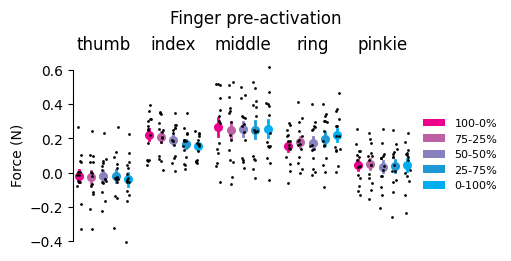

In [183]:
behav = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'behaviour.trial.tsv'), sep='\t')
behav_cue_avg = behav.groupby(['sn', 'cue']).mean(numeric_only=True).reset_index()
fig, axs = plt.subplots(1, 5, sharey=True, figsize=(5, 2.5), constrained_layout=True)
for f, finger in enumerate(gl.fingers):
    ax = axs[f]
    plot_binned_cue(fig, ax, behav_cue_avg, y=f'{finger}0', x='cue', show_individuals=True)
    ax.legend(frameon=False) if f<4 else None
    ax.spines[['left']].set_visible(False)
    ax.tick_params(left=False)
    ax.set_title(finger)
axs[0].tick_params(left=True)
axs[0].spines[['left']].set_visible(True)
axs[0].spines[['left']].set_bounds(-.4, .6)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Finger pre-activation')
fig.savefig(os.path.join('figures', 'preactivation.force.pdf'))
for finger in gl.fingers:
    dv = f'{finger}0'
    aov = pg.rm_anova(
        data=behav_cue_avg,
        dv=dv,
        within='cue',
        subject='sn',
        detailed=True
    )
    print(f'\nRM-ANOVA for {finger}')
    print(aov)
plt.show()

force: tval=3.2576122221408705, pval=0.0031180970089363883


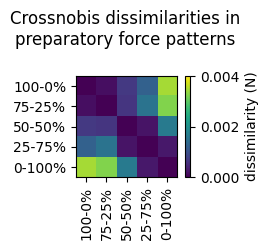

In [184]:
behav_block_cue = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'behaviour.block.cue.tsv'), sep='\t')
G_force, G_force_der = calc_G_force(behav_block_cue, prewhiten=False)
D_force = pcm.G_to_dist(G_force)
vmin, vmax = 0, .004
fig, ax = plt.subplots(figsize=(3, 2.5))
fig, ax = plot_rdm(fig, ax, None, D_force, list(gl.regressor_mapping.keys())[:5],sqrt=False, source='force', vmin=vmin, vmax=vmax)
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.04)
cbar.set_label('dissimilarity (N)')
fig.suptitle('Crossnobis dissimilarities in\npreparatory force patterns')
fig.tight_layout()
fig.savefig(os.path.join('figures', 'crossnobis.force.pdf'))
plt.show()


RM-ANOVA for thumb
  Source        SS  DF        MS         F     p-unc       ng2       eps
0    cue  0.001458   4  0.000365  0.290632  0.882755  0.000063  0.758938
1  Error  0.065229  52  0.001254       NaN       NaN       NaN       NaN

RM-ANOVA for index
  Source        SS  DF        MS         F     p-unc       ng2       eps
0    cue  0.014000   4  0.003500  2.890998  0.030957  0.001098  0.650096
1  Error  0.062953  52  0.001211       NaN       NaN       NaN       NaN

RM-ANOVA for middle
  Source        SS  DF       MS        F     p-unc      ng2       eps
0    cue  0.000958   4  0.00024  0.14973  0.962302  0.00003  0.847517
1  Error  0.083200  52  0.00160      NaN       NaN      NaN       NaN

RM-ANOVA for ring
  Source        SS  DF        MS         F   p-unc       ng2       eps
0    cue  0.020248   4  0.005062  3.429464  0.0146  0.001346  0.454733
1  Error  0.076753  52  0.001476       NaN     NaN       NaN       NaN

RM-ANOVA for pinkie
  Source        SS  DF        MS      

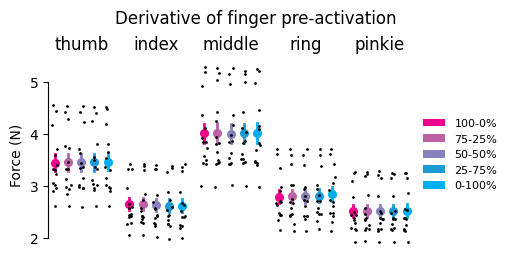

In [185]:
fig, axs = plt.subplots(1, 5, sharey=True, figsize=(5, 2.5), constrained_layout=True)
for f, finger in enumerate(gl.fingers):
    ax = axs[f]
    plot_binned_cue(fig, ax, behav_cue_avg, y=f'{finger}_der0', x='cue', show_individuals=True)
    ax.legend(frameon=False) if f<4 else None
    ax.spines[['left']].set_visible(False)
    ax.tick_params(left=False)
    ax.set_title(finger)
axs[0].tick_params(left=True)
axs[0].spines[['left']].set_visible(True)
axs[0].spines[['left']].set_bounds(2, 5)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Derivative of finger pre-activation')
fig.savefig(os.path.join('figures', 'preactivation.derivative.pdf'))
for finger in gl.fingers:
    dv = f'{finger}_der0'
    aov = pg.rm_anova(
        data=behav_cue_avg,
        dv=dv,
        within='cue',
        subject='sn',
        detailed=True)
    print(f'\nRM-ANOVA for {finger}')
    print(aov)
plt.show()

force: tval=-0.32262402734735257, pval=0.623944996744814


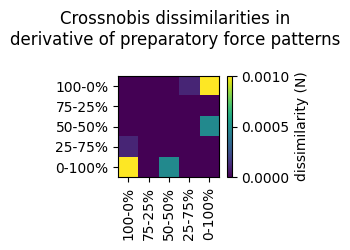

In [186]:
D_force_der = pcm.G_to_dist(G_force_der)
vmin, vmax = 0, .001
fig, ax = plt.subplots(figsize=(3, 2.5))
fig, ax = plot_rdm(fig, ax, None, D_force_der, list(gl.regressor_mapping.keys())[:5],sqrt=False, source='force', vmin=vmin, vmax=vmax)
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.04)
cbar.set_label('dissimilarity (N)')
fig.suptitle('Crossnobis dissimilarities in\nderivative of preparatory force patterns')
fig.tight_layout()
fig.savefig(os.path.join('figures', 'crossnobis.force_derivative.pdf'))
plt.show()

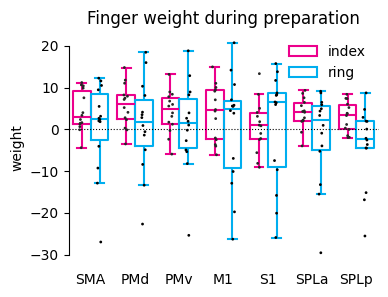

In [187]:
H = 'L'
atlas = 'ROI'
rois = gl.rois[atlas]
preact_weights = pd.read_csv(os.path.join(gl.baseDir, 'smp2', f'glm12', 'ROI.preactivation_weights.tsv'), sep='\t')
preact_weights_melt = pd.melt(preact_weights, id_vars=['Hem', 'roi', 'sn'], value_vars=['index', 'ring'], value_name='weight', var_name='finger')
preact_weights_melt = preact_weights_melt[preact_weights_melt.Hem==H]
fig, ax = plt.subplots(figsize=(4, 3))
palette = [list(gl.colour_mapping.values())[0], list(gl.colour_mapping.values())[4]]
# sb.pointplot(data=preact_weights_melt, ax=ax, x='roi', y='weight', hue='finger', errorbar='se', palette=palette, ls='none', dodge=.4, lw=2)
sb.boxplot(data=preact_weights_melt, ax=ax, x='roi', y='weight', hue='finger', palette=palette, fill=False, showfliers=False)
sb.stripplot(data=preact_weights_melt, ax=ax, x='roi', y='weight', hue='finger', dodge=True, color='k', size=2, legend=False)
ax.axhline(0, color='k', ls=':', lw=.8)
ax.legend(frameon=False, loc='upper right',)
ax.set_xlabel('')
ax.tick_params(bottom=False)
ax.spines[['left']].set_bounds((-30, 20))
ax.spines[['bottom', 'right', 'top']].set_visible(False)

ax.set_title('Finger weight during preparation')

plt.show()

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=1.8842865350652842, pval=0.041040957018755986
PMd: tval=3.265034827303115, pval=0.0030738705348276555
PMv: tval=2.9469599082691293, pval=0.00566894426683502
M1: tval=3.3832462545926796, pval=0.0024487416991953027
S1: tval=4.1526114496004265, pval=0.0005678340178985813
SPLa: tval=3.322002721003307, pval=0.002754756206013128
SPLp: tval=3.9087054241031285, pval=0.0008981751836551068


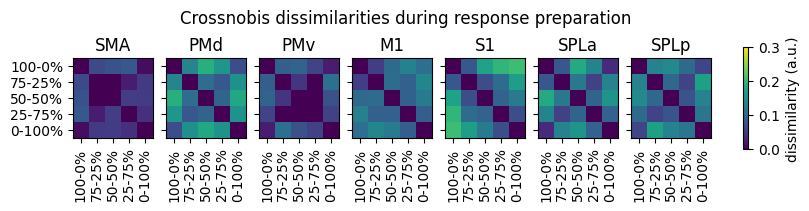

In [188]:
vmin, vmax = 0, .3

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
tr_null_plan, tr_pot_plan = [], []
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.regr_out_preact_ols.glm12.{H}.{roi}.npy'))
    tr_null_plan.append(np.trace(G, axis1=1, axis2=2))
    D = pcm.G_to_dist(G)
    fig, axs = plot_rdm(fig, axs, r, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response preparation')
fig.savefig(os.path.join('figures', 'crossnobis.plan.preactivation_out.pdf'))
plt.show()

T  dof alternative     p-val  \
roi  dataset                                                         
M1   original          T-test  2.446785   13     greater  0.014695   
     preactivation out T-test  1.764203   13     greater  0.050583   
PMd  original          T-test  3.697104   13     greater  0.001342   
     preactivation out T-test  2.123295   13     greater  0.026749   
PMv  original          T-test  1.618486   13     greater  0.064776   
     preactivation out T-test  0.751616   13     greater  0.232836   
S1   original          T-test  3.397400   13     greater  0.002383   
     preactivation out T-test  2.708273   13     greater  0.008955   
SMA  original          T-test  1.081856   13     greater  0.149488   
     preactivation out T-test  0.341115   13     greater  0.369234   
SPLa original          T-test  3.034924   13     greater  0.004787   
     preactivation out T-test  1.730185   13     greater  0.053625   
SPLp original          T-test  3.251405   13     greater  0.003156   
     preactivation out T-test  1.817720   13     greater  0.046109   

                                      CI95%   cohen-d    BF10     power  
roi  dataset                                                             
M1   original          T-test   [5.97, inf]  0.653931   4.765  0.749094  
     preactivation out T-test  [-0.06, inf]  0.471503   1.853  0.510643  
PMd  original          T-test   [5.15, inf]  0.988093  33.877  0.967881  
     preactivation out T-test   [0.75, inf]  0.567474   2.988  0.642856  
PMv  original          T-test  [-0.12, inf]  0.432559    1.55  0.455756  
     preactivation out T-test  [-0.63, inf]  0.200878   0.689  0.175691  
S1   original          T-test  [34.48, inf]  0.907993  20.947  0.941587  
     preactivation out T-test  [10.82, inf]  0.723816   7.074  0.820810  
SMA  original          T-test  [-0.58, inf]  0.289138   0.886  0.267945  
     preactivation out T-test  [-1.19, inf]  0.091167   0.568  0.093227  
SPLa original          T-test   [2.44, inf]  0.811117  11.768  0.890010  
     preactivation out T-test  [-0.08, inf]  0.462411   1.776  0.497811  
SPLp original          T-test   [3.25, inf]  0.868974  16.589  0.923736  
     preactivation out T-test   [0.05, inf]  0.485806   1.984  0.530801

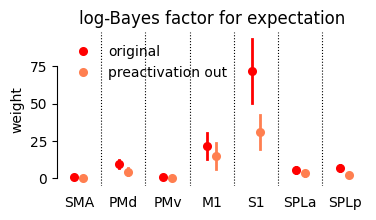

In [189]:
comp_model = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
comp_model = comp_model[(comp_model.dataset.isin(['plan', 'regr_out_preact_ols'])) & (comp_model.Hem==H)]
comp_model['norm_weight'] = np.sqrt(comp_model['weight'] / comp_model['noise'])
comp_model.dataset = comp_model.dataset.map({'plan': 'original', 'regr_out_preact_ols': 'preactivation out'})
comp_model_exp = comp_model[comp_model.component=='expectation']
comp_model_unc = comp_model[comp_model.component=='uncertainty']
sep = [.5, 1.5, 2.5, 3.5, 4.5, 5.5]

fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_exp, x='roi', y='BF', hue='dataset', palette=['red', 'coral'], errorbar='se', linestyles='none', dodge=.2, lw=2)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, 75)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for expectation')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
results = comp_model_exp.groupby(['roi', 'dataset']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)
plt.show()

T  dof alternative     p-val  \
roi  dataset                                                         
M1   original          T-test  1.420972   13     greater  0.089433   
     preactivation out T-test  1.488956   13     greater  0.080177   
PMd  original          T-test  2.108148   13     greater  0.027496   
     preactivation out T-test  2.117808   13     greater  0.027018   
PMv  original          T-test  2.124096   13     greater  0.026710   
     preactivation out T-test  2.131148   13     greater  0.026370   
S1   original          T-test  2.164677   13     greater  0.024804   
     preactivation out T-test  2.270184   13     greater  0.020427   
SMA  original          T-test  1.570233   13     greater  0.070186   
     preactivation out T-test  1.581252   13     greater  0.068918   
SPLa original          T-test  1.675392   13     greater  0.058864   
     preactivation out T-test  1.720968   13     greater  0.054476   
SPLp original          T-test  2.985036   13     greater  0.005269   
     preactivation out T-test  2.919450   13     greater  0.005977   

                                      CI95%   cohen-d    BF10     power  
roi  dataset                                                             
M1   original          T-test  [-0.47, inf]  0.379771   1.238  0.382850  
     preactivation out T-test  [-0.37, inf]  0.397940   1.334  0.407619  
PMd  original          T-test   [4.07, inf]  0.563426   2.926  0.637503  
     preactivation out T-test   [4.07, inf]  0.566008   2.966  0.640920  
PMv  original          T-test   [0.56, inf]  0.567689   2.992  0.643139  
     preactivation out T-test   [0.59, inf]  0.569573   3.021  0.645621  
S1   original          T-test   [0.56, inf]  0.578534   3.167  0.657335  
     preactivation out T-test   [0.72, inf]  0.606732    3.68  0.693175  
SMA  original          T-test  [-0.31, inf]  0.419662   1.464  0.437710  
     preactivation out T-test  [-0.28, inf]  0.422607   1.483  0.441821  
SPLa original          T-test  [-0.99, inf]  0.447767    1.66  0.477150  
     preactivation out T-test  [-0.48, inf]  0.459948   1.756  0.494334  
SPLp original          T-test   [6.47, inf]  0.797784  10.879  0.880908  
     preactivation out T-test   [5.82, inf]  0.780256   9.815  0.868149

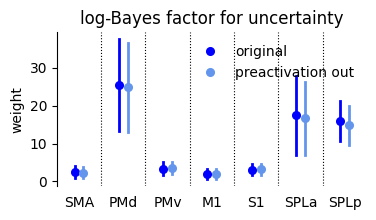

In [190]:
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_unc, x='roi', y='BF', hue='dataset', palette=['blue', 'cornflowerblue'], errorbar='se', linestyles='none', lw=2, dodge=.2)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
axs[0].spines[['left']].set_bounds(0, 30)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for uncertainty')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
results = comp_model_unc.groupby(['roi', 'dataset']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)
plt.show()

,,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
roi,,,,,,,,,,,,
M1,0,dataset,original,preactivation out,True,True,1.788112,13.0,greater,0.048538,1.91,0.260478
PMd,0,dataset,original,preactivation out,True,True,2.536785,13.0,greater,0.012402,5.451,0.324426
PMv,0,dataset,original,preactivation out,True,True,2.422306,13.0,greater,0.015386,4.595,0.239808
S1,0,dataset,original,preactivation out,True,True,2.019204,13.0,greater,0.032289,2.589,0.534441
SMA,0,dataset,original,preactivation out,True,True,0.899650,13.0,greater,0.192334,0.764,0.165125
SPLa,0,dataset,original,preactivation out,True,True,1.742844,13.0,greater,0.052474,1.804,0.249488
SPLp,0,dataset,original,preactivation out,True,True,2.519505,13.0,greater,0.012814,5.311,0.469749


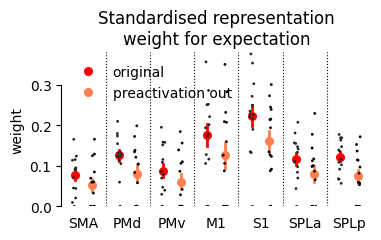

In [191]:
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_exp, x='roi', y='norm_weight', hue='dataset', palette=['red', 'coral'], errorbar='se', linestyles='none', lw=2, dodge=.4)
sb.stripplot(ax=ax, data=comp_model_exp, x='roi', y='norm_weight', hue='dataset', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, .3)
ax.set_ylim(0, .38)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation\nweight for expectation')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
results = comp_model_exp.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='dataset', subject='participant_id', alternative='greater'))
display(results)
fig.savefig(os.path.join('figures', 'weight.plan.preact_out.expectation.pdf'))
plt.show()

,,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
roi,,,,,,,,,,,,
M1,0,dataset,original,preactivation out,True,True,0.169246,13.0,greater,0.434104,0.547,0.006159
PMd,0,dataset,original,preactivation out,True,True,0.820937,13.0,greater,0.213240,0.722,0.025998
PMv,0,dataset,original,preactivation out,True,True,0.327441,13.0,greater,0.374274,0.566,0.011899
S1,0,dataset,original,preactivation out,True,True,0.102836,13.0,greater,0.459831,0.542,0.005524
SMA,0,dataset,original,preactivation out,True,True,-0.638183,13.0,greater,0.732782,0.645,-0.029985
SPLa,0,dataset,original,preactivation out,True,True,1.052776,13.0,greater,0.155810,0.864,0.027031
SPLp,0,dataset,original,preactivation out,True,True,1.883575,13.0,greater,0.041092,2.16,0.064580


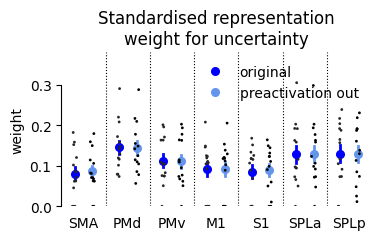

In [192]:
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_unc, x='roi', y='norm_weight', hue='dataset', palette=['blue', 'cornflowerblue'], errorbar='se', linestyles='none', lw=2, dodge=.4)
sb.stripplot(ax=ax, data=comp_model_unc, x='roi', y='norm_weight', hue='dataset', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, .3)
ax.set_ylim(0, .38)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation\nweight for uncertainty')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
results = comp_model_unc.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='dataset', subject='participant_id', alternative='greater'))
display(results)
fig.savefig(os.path.join('figures', 'weight.plan.preact_out.uncertainty.pdf'))
plt.show()

,,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
roi,,,,,,,,,,,,
M1,0,component,expectation,uncertainty,True,True,1.851802,13.0,greater,0.043448,2.073,0.613470
PMd,0,component,expectation,uncertainty,True,True,-1.694879,13.0,greater,0.943049,0.588,-0.471320
PMv,0,component,expectation,uncertainty,True,True,-1.683802,13.0,greater,0.941968,0.596,-0.616717
S1,0,component,expectation,uncertainty,True,True,2.743449,13.0,greater,0.008373,7.467,0.948875
SMA,0,component,expectation,uncertainty,True,True,-1.070470,13.0,greater,0.848060,0.877,-0.308076
SPLa,0,component,expectation,uncertainty,True,True,-1.104262,13.0,greater,0.855250,0.904,-0.392866
SPLp,0,component,expectation,uncertainty,True,True,-1.670846,13.0,greater,0.940681,0.606,-0.639660


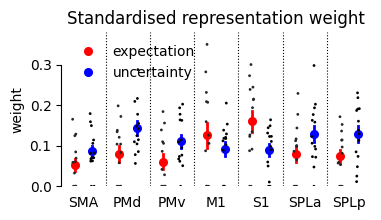

In [193]:
comp_model_regr_out = comp_model[comp_model.dataset=='preactivation out']
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_regr_out, x='roi', y='norm_weight', hue='component', palette=['red', 'blue'], errorbar='se', linestyles='none', lw=2, dodge=.4)
sb.stripplot(ax=ax, data=comp_model_regr_out, x='roi', y='norm_weight', hue='component', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, .3)
ax.set_ylim(0, .38)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
results = comp_model_regr_out.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id', alternative='greater'))
display(results)
fig.savefig(os.path.join('figures', 'weight.plan.preact_out.pdf'))
plt.show()

T  dof alternative     p-val         CI95%  \
roi  group                                                             
M1   False T-test  1.785623    6     greater  0.062202  [-2.62, inf]   
     True  T-test  2.141098    6     greater  0.038017   [1.25, inf]   
PMd  False T-test  1.895705    6     greater  0.053402  [-0.17, inf]   
     True  T-test  3.361658    6     greater  0.007599   [5.51, inf]   
PMv  False T-test  0.652314    6     greater  0.269186  [-1.23, inf]   
     True  T-test  1.507184    6     greater  0.091242  [-0.56, inf]   
S1   False T-test  2.815116    6     greater  0.015275  [17.24, inf]   
     True  T-test  2.307148    6     greater  0.030252  [13.94, inf]   
SMA  False T-test  0.676712    6     greater  0.261903  [-2.07, inf]   
     True  T-test  1.102232    6     greater  0.156300  [-0.56, inf]   
SPLa False T-test  1.484135    6     greater  0.094152  [-1.49, inf]   
     True  T-test  3.016643    6     greater  0.011749   [2.45, inf]   
SPLp False T-test  1.540271    6     greater  0.087212  [-1.06, inf]   
     True  T-test  3.111427    6     greater  0.010405   [3.84, inf]   

                    cohen-d   BF10     power  
roi  group                                    
M1   False T-test  0.674902  2.059  0.474882  
     True  T-test  0.809259  2.921  0.598068  
PMd  False T-test  0.716509  2.291  0.513378  
     True  T-test  1.270587  9.734  0.904694  
PMv  False T-test  0.246551  0.841  0.143778  
     True  T-test  0.569662  1.585  0.379156  
S1   False T-test  1.064014   5.73  0.798298  
     True  T-test  0.872020   3.45  0.652985  
SMA  False T-test  0.255773  0.851  0.148744  
     True  T-test  0.416604  1.126  0.253069  
SPLa False T-test  0.560950  1.552  0.371461  
     True  T-test  1.140184  6.985  0.843836  
SPLp False T-test  0.582168  1.634  0.390282  
     True  T-test  1.176009  7.659  0.862679

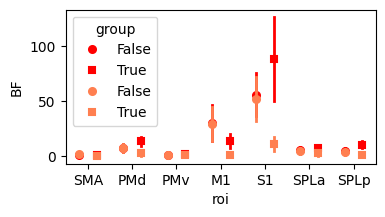

In [194]:
behav_100_avg = behav[behav.cue.isin(['100-0%', '0-100%'])].groupby(['sn',]).mean(numeric_only=True).reset_index()
forceDiff_median = behav_100_avg.forceDiff.median()
behav_100_avg['group'] = behav_100_avg.forceDiff > forceDiff_median
#behav_100_avg.group = behav_100_avg.group.map({True: 'high pre-activation', False: 'low pre-activation'})
comp_model_exp['sn'] = comp_model_exp.participant_id
comp_model_exp_g = comp_model_exp.merge(behav_100_avg[['sn', 'group']], on='sn',)
comp_model_exp_g = comp_model_exp_g[['participant_id', 'roi', 'norm_weight', 'BF', 'group', 'weight', 'dataset']]

fig, ax = plt.subplots(figsize=(4, 2))

sb.pointplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='original'], x='roi', y='BF', 
    hue='group', palette=['r', 'r'], markers=['o', 's'], errorbar='se', linestyles='none', lw=2, dodge=.4, hue_order=[False, True])
sb.pointplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='preactivation out'], x='roi', y='BF', 
    hue='group', palette=['coral', 'coral'], markers=['o', 's'], errorbar='se', linestyles='none', lw=2, dodge=.4, hue_order=[False, True])

results = comp_model_exp_g[comp_model_exp_g.dataset=='original'].groupby(['roi', 'group']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)

plt.show()

,roi,dataset,level_2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power,n_high,n_low
0,M1,original,T-test,-0.402179,12,greater,0.652688,"[-0.12, inf]",0.214974,0.941,0.021423,7,7
1,M1,preactivation out,T-test,-2.056616,12,greater,0.968929,"[-0.22, inf]",1.099308,0.321,0.000163,7,7
2,PMd,original,T-test,1.737777,12,greater,0.053910,"[-0.0, inf]",0.928881,2.243,0.497625,7,7
3,PMd,preactivation out,T-test,-1.339063,12,greater,0.897318,"[-0.11, inf]",0.715759,0.636,0.001791,7,7
4,PMv,original,T-test,1.178407,12,greater,0.130737,"[-0.02, inf]",0.629885,1.391,0.297128,7,7
5,PMv,preactivation out,T-test,-0.334733,12,greater,0.628197,"[-0.08, inf]",0.178922,0.926,0.024916,7,7
6,S1,original,T-test,0.928506,12,greater,0.185723,"[-0.04, inf]",0.496307,1.18,0.221171,7,7
7,S1,preactivation out,T-test,-1.398183,12,greater,0.906318,"[-0.16, inf]",0.747360,0.606,0.001494,7,7
8,SMA,original,T-test,1.071101,12,greater,0.152597,"[-0.02, inf]",0.572528,1.291,0.263102,7,7
9,SMA,preactivation out,T-test,-0.988757,12,greater,0.828850,"[-0.08, inf]",0.528513,0.817,0.004930,7,7


,roi,level_1,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,M1,0,group,0.033645,1,12,0.033645,1.789853,0.205746,0.129795,NaN
1,M1,1,dataset,0.017585,1,12,0.017585,5.465070,0.037539,0.312914,1.0
2,M1,2,Interaction,0.015438,1,12,0.015438,4.797922,0.048971,0.285626,NaN
3,PMd,0,group,0.000039,1,12,0.000039,0.006872,0.935298,0.000572,NaN
4,PMd,1,dataset,0.014848,1,12,0.014848,12.565830,0.004035,0.511517,1.0
5,PMd,2,Interaction,0.015115,1,12,0.015115,12.792258,0.003806,0.515978,NaN
6,PMv,0,group,0.001175,1,12,0.001175,0.151305,0.704106,0.012452,NaN
7,PMv,1,dataset,0.005267,1,12,0.005267,6.318495,0.027224,0.344924,1.0
8,PMv,2,Interaction,0.004535,1,12,0.004535,5.440400,0.037900,0.311942,NaN
9,S1,0,group,0.000786,1,12,0.000786,0.055050,0.818454,0.004567,NaN


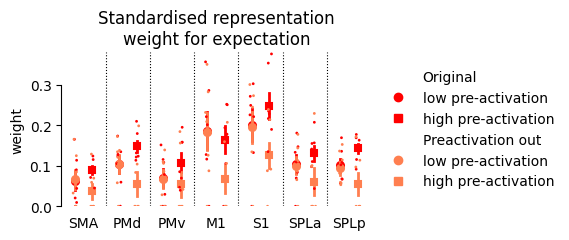

In [195]:
fig, ax = plt.subplots(figsize=(4, 2))

sb.pointplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='original'], x='roi', y='norm_weight', 
    hue='group', palette=['r', 'r'], markers=['o', 's'], errorbar='se', linestyles='none', lw=2, dodge=.4, hue_order=[False, True])
sb.pointplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='preactivation out'], x='roi', y='norm_weight', 
    hue='group', palette=['coral', 'coral'], markers=['o', 's'], errorbar='se', linestyles='none', lw=2, dodge=.4, hue_order=[False, True])
sb.stripplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='original'], x='roi', y='norm_weight', 
    hue='group', size=2, palette=['r', 'r'], jitter=.1, dodge=True, legend=False, hue_order=[False, True])
sb.stripplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='preactivation out'], x='roi', y='norm_weight', 
    hue='group', size=2, palette=['coral', 'coral'], jitter=.1, dodge=True, legend=False, hue_order=[False, True])
    
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, .3)
ax.set_ylim(0, .38)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation\nweight for expectation')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')

handles = [
    Line2D([], [], linestyle='none', label='Original'),
    Line2D([0], [0], marker='o', color='r', linestyle='none', label='low pre-activation'),
    Line2D([0], [0], marker='s', color='r', linestyle='none', label='high pre-activation'),
    
    Line2D([], [], linestyle='none', label='Preactivation out'),
    Line2D([0], [0], marker='o', color='coral', linestyle='none', label='low pre-activation'),
    Line2D([0], [0], marker='s', color='coral', linestyle='none', label='high pre-activation'),
]

ax.legend(handles=handles, frameon=False, loc='center left', bbox_to_anchor=(1, .5))

fig.savefig(os.path.join('figures', 'weight.plan.preact_out_vs_original.expectation.pdf'))

results_ttest = (
    comp_model_exp_g
    .groupby(['roi', 'dataset'])
    .apply(lambda g: pg.ttest(
        g.loc[g['group'], 'norm_weight'],          # high
        g.loc[~g['group'], 'norm_weight'],         # low
        alternative='greater'
    ).assign(
        n_high = g['group'].sum(),
        n_low  = (~g['group']).sum()
    ))
    .reset_index()
)

display(results_ttest)

anova_results = (
    comp_model_exp_g
    .groupby('roi')
    .apply(lambda g: pg.mixed_anova(
        data=g,
        dv='norm_weight',
        within='dataset',
        between='group',
        subject='participant_id'
    ))
    .reset_index()
)

display(anova_results)

plt.show()